In [21]:
import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# sklearn 텍스트 출력 설정
sklearn.set_config(display='text')

# 1. 전처리된 데이터 로드
df = joblib.load('quality_prep(1).pkl')

# 2. 데이터 추출
X_train = df['X_train']
X_test = df['X_test']
y_train_raw = df['y_train']  # 문자열 데이터 ('Low', 'Medium', 'High')
y_test_raw = df['y_test']
preprocessor = df.get('preprocessor', None)

# 문자열 라벨('Low', 'Medium', 'High')을 수치(0, 1, 2)로 변환

label_map = {'Low': 0, 'Medium': 1, 'High': 2}

# 문자열을 숫자로 매핑 
if isinstance(y_train_raw.iloc[0] if hasattr(y_train_raw, 'iloc') else y_train_raw[0], str):
    y_train = y_train_raw.map(label_map) if hasattr(y_train_raw, 'map') else pd.Series(y_train_raw).map(label_map)
    y_test = y_test_raw.map(label_map) if hasattr(y_test_raw, 'map') else pd.Series(y_test_raw).map(label_map)
else:
    y_train = y_train_raw
    y_test = y_test_raw

# 3. 선형 회귀(Linear Regression) 모델 생성 및 학습
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)  # 이제 숫자로 변환되었으므로 정상 학습됨!

print("=== 학습 완료 ===\n")

# 4. 예측 수행
y_pred = model.predict(X_test)

# 5. 회귀 성능 평가 지표 계산
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== 선형 회귀 핵심 성능 지표 ===")
print(f"1. MAE  (평균 절대 오차) : {mae:.4f}")
print(f"2. MSE  (평균 제곱 오차) : {mse:.4f}")
print(f"3. RMSE (제곱근 평균 오차): {rmse:.4f}")
print(f"4. R² Score (결정계수)   : {r2:.4f}\n")

# 6. 피처별 회귀 계수(Feature Coefficients) 추출
if preprocessor and hasattr(preprocessor, 'get_feature_names_out'):
    feature_names = preprocessor.get_feature_names_out()
else:
    feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("=== 피처별 회귀 계수 (Feature Coefficients) ===")
print(coef_df)
print("\n")




=== 학습 완료 ===

=== 선형 회귀 핵심 성능 지표 ===
1. MAE  (평균 절대 오차) : 0.1481
2. MSE  (평균 제곱 오차) : 0.0447
3. RMSE (제곱근 평균 오차): 0.2115
4. R² Score (결정계수)   : 0.8515

=== 피처별 회귀 계수 (Feature Coefficients) ===
                         Feature  Coefficient
10      cat__BMI Category_Normal     0.496045
0                       num__Age     0.395404
9               cat__Gender_Male     0.211650
4                num__Heart Rate     0.149300
5               num__Daily Steps     0.121917
6               num__Systolic BP     0.094799
2   num__Physical Activity Level     0.079723
12  cat__BMI Category_Overweight    -0.133869
8             cat__Gender_Female    -0.211650
7              num__Diastolic BP    -0.220365
1            num__Sleep Duration    -0.305777
11       cat__BMI Category_Obese    -0.362176
3              num__Stress Level    -0.627271




In [16]:
!pip install matplotlib

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl (73 kB)
Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
pip install  seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


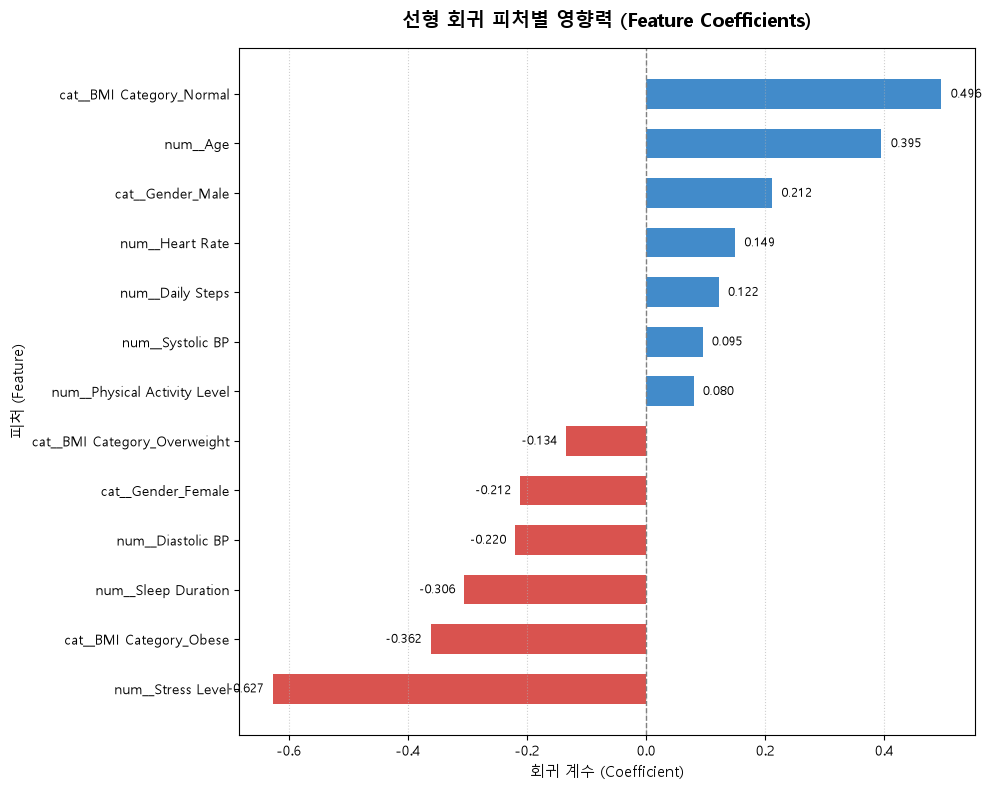

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 2. 그래프 스타일 및 크기 설정
plt.figure(figsize=(10, 8))

# 계수 크기 기준으로 정렬된 데이터
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=True)

# 양수(상승 요인)는 파란색, 음수(감소 요인)는 빨간색/주황색 계열로 구분
colors = ['#d9534f' if val < 0 else '#428bca' for val in coef_df_sorted['Coefficient']]

# 3. 수평 막대그래프 그리기
bars = plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors, edgecolor='none', height=0.6)

# 기준선(0점) 표시
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# 4. 막대 옆에 수치 값(Text) 표시
for bar in bars:
    width = bar.get_width()
    offset = 0.015 if width >= 0 else -0.015
    ha = 'left' if width >= 0 else 'right'
    plt.text(
        width + offset, 
        bar.get_y() + bar.get_height()/2, 
        f'{width:.3f}', 
        va='center', 
        ha=ha, 
        fontsize=9, 
        color='black'
    )

# 5. 차트 제목 및 라벨 설정
plt.title('선형 회귀 피처별 영향력 (Feature Coefficients)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('회귀 계수 (Coefficient)', fontsize=11)
plt.ylabel('피처 (Feature)', fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 5-Fold 교차 검증 수행 (R2 Score)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

print("=== 5-Fold 교차 검증 결과 ===")
print(f"각 Fold별 R² 점수 : {np.round(scores, 4)}")
print(f"평균 R² 점수      : {scores.mean():.4f}")
print(f"R² 표준편차       : {scores.std():.4f}")

=== 5-Fold 교차 검증 결과 ===
각 Fold별 R² 점수 : [0.7551 0.8061 0.8598 0.8465 0.8649]
평균 R² 점수      : 0.8265
R² 표준편차       : 0.0412


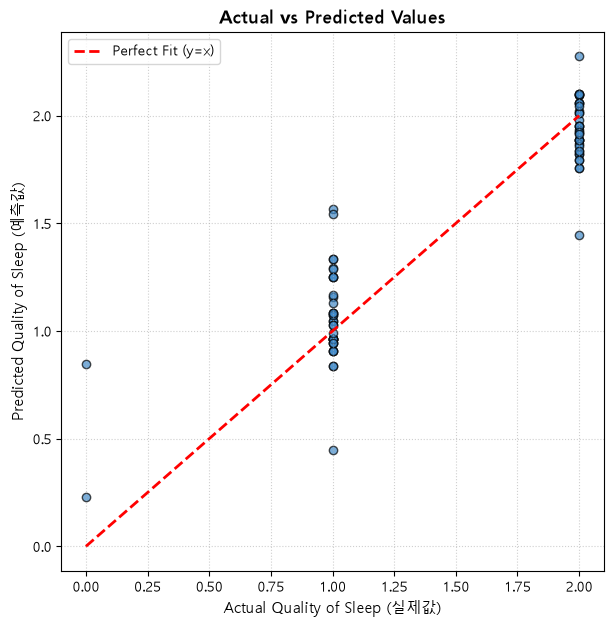

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7, color='#428bca', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit (y=x)')

plt.title('Actual vs Predicted Values', fontsize=13, fontweight='bold')
plt.xlabel('Actual Quality of Sleep (실제값)', fontsize=11)
plt.ylabel('Predicted Quality of Sleep (예측값)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()